# Ensemble (Voting) — Combinação de Modelos
Combina as probabilidades dos modelos treinados via média simples e ponderada.
Cada pipeline já inclui seu próprio preprocessador — carrega-se diretamente os `.joblib`.
Métricas prioritárias: **Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1**

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.metrics import (
    precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

BASE_DIR   = '../../data/features/baseline'
OUTPUT_MOD = '../../output/modelos'
OUTPUT_MET = '../../output/metricas'
YEAR_COL   = 'year'

## 1. Carregamento dos dados

In [2]:
X_test = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

y_te      = y_test.dropna()
test_mask = y_test.notna().values

def prep_X(df):
    df = df.copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df.drop(columns=[YEAR_COL], errors='ignore')

X_test_prep = prep_X(X_test)

print(f'X_test: {X_test_prep.shape} | Óbitos: {int(y_te.sum()):,} ({y_te.mean()*100:.2f}%)')

X_test: (160534, 51) | Óbitos: 5,295 (3.30%)


## 2. Carregamento dos modelos
Cada pipeline contém seu próprio preprocessador — `predict_proba` recebe o X_test bruto.

In [3]:
modelos = {
    'lr':           joblib.load(os.path.join(OUTPUT_MOD, 'logistic_regression_baseline.joblib')),
    'lr_tuned':     joblib.load(os.path.join(OUTPUT_MOD, 'logistic_regression_baseline_tuned.joblib')),
    'mlp':          joblib.load(os.path.join(OUTPUT_MOD, 'mlp_baseline.joblib')),
    'xgb_tuned':    joblib.load(os.path.join(OUTPUT_MOD, 'xgboost_baseline_tuned.joblib')),
    'lgbm_tuned':   joblib.load(os.path.join(OUTPUT_MOD, 'lightgbm_baseline_tuned.joblib')),
}

print('Modelos carregados:', list(modelos.keys()))

Modelos carregados: ['lr', 'lr_tuned', 'mlp', 'xgb_tuned', 'lgbm_tuned']


## 3. Probabilidades individuais

In [4]:
def calcular_metricas(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'auprc':          round(average_precision_score(y_true, y_pred_proba), 4),
        'roc_auc':        round(roc_auc_score(y_true, y_pred_proba), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'precisao':       round(precision_score(y_true, y_pred, zero_division=0), 4),
        'threshold':      threshold,
    }

probas = {}
print(f'{'Modelo':<20} {'Sensibilidade':>14} {'AUPRC':>8} {'ROC-AUC':>9}')
print('-' * 55)
for nome, modelo in modelos.items():
    p = modelo.predict_proba(X_test_prep)[:, 1][test_mask]
    probas[nome] = p
    m = calcular_metricas(y_te, p)
    print(f'{nome:<20} {m["sensibilidade"]:>14.4f} {m["auprc"]:>8.4f} {m["roc_auc"]:>9.4f}')

Modelo                Sensibilidade    AUPRC   ROC-AUC
-------------------------------------------------------
lr                           0.8004   0.6250    0.9242
lr_tuned                     0.8008   0.6250    0.9242
mlp                          0.7843   0.6369    0.9217
xgb_tuned                    0.7932   0.6314    0.9194
lgbm_tuned                   0.7549   0.6294    0.9136


## 4. Combinações de ensemble — média simples
Testa todas as combinações de 2, 3, 4 e 5 modelos. Ordena por AUPRC.

In [5]:
nomes = list(probas.keys())
rows  = []

for r in range(2, len(nomes) + 1):
    for combo in combinations(nomes, r):
        p_ensemble = np.mean([probas[n] for n in combo], axis=0)
        m = calcular_metricas(y_te, p_ensemble)
        rows.append({'modelos': ' + '.join(combo), **m})

df_combos = pd.DataFrame(rows).sort_values('auprc', ascending=False)
display(df_combos[['modelos', 'sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1']].head(15))

,modelos,sensibilidade,especificidade,auprc,roc_auc,f1
21,lr + lr_tuned + mlp + lgbm_tuned,0.7843,0.9087,0.6472,0.9261,0.3517
17,lr_tuned + mlp + lgbm_tuned,0.7794,0.9141,0.6471,0.9257,0.3627
14,lr + mlp + lgbm_tuned,0.7792,0.9141,0.6471,0.9256,0.3626
25,lr + lr_tuned + mlp + xgb_tuned + lgbm_tuned,0.7894,0.9056,0.6467,0.9258,0.3464
23,lr + mlp + xgb_tuned + lgbm_tuned,0.7862,0.9090,0.6462,0.9251,0.3530
24,lr_tuned + mlp + xgb_tuned + lgbm_tuned,0.7862,0.9091,0.6462,0.9251,0.3532
16,lr_tuned + mlp + xgb_tuned,0.7926,0.8993,0.6450,0.9255,0.3341
13,lr + mlp + xgb_tuned,0.7928,0.8992,0.6450,0.9255,0.3339
20,lr + lr_tuned + mlp + xgb_tuned,0.7947,0.8968,0.6445,0.9258,0.3297
12,lr + lr_tuned + lgbm_tuned,0.7856,0.9056,0.6442,0.9257,0.3451


## 5. Ensemble ponderado — LR + MLP
Testa pesos variando de 0.1 a 0.9 para LR, complementar para MLP.

,w_lr,w_mlp,sensibilidade,especificidade,auprc,roc_auc,f1
0,0.1,0.9,0.7849,0.9074,0.6380,0.9228,0.3489
1,0.2,0.8,0.7856,0.9064,0.6387,0.9237,0.3468
2,0.3,0.7,0.7866,0.9049,0.6392,0.9244,0.3439
3,0.4,0.6,0.7877,0.9029,0.6393,0.9249,0.3400
4,0.5,0.5,0.7892,0.9006,0.6391,0.9252,0.3357
5,0.6,0.4,0.7921,0.8981,0.6386,0.9253,0.3315
6,0.7,0.3,0.7932,0.8956,0.6376,0.9253,0.3267
7,0.8,0.2,0.7940,0.8924,0.6362,0.9251,0.3209
8,0.9,0.1,0.7981,0.8890,0.6338,0.9248,0.3159


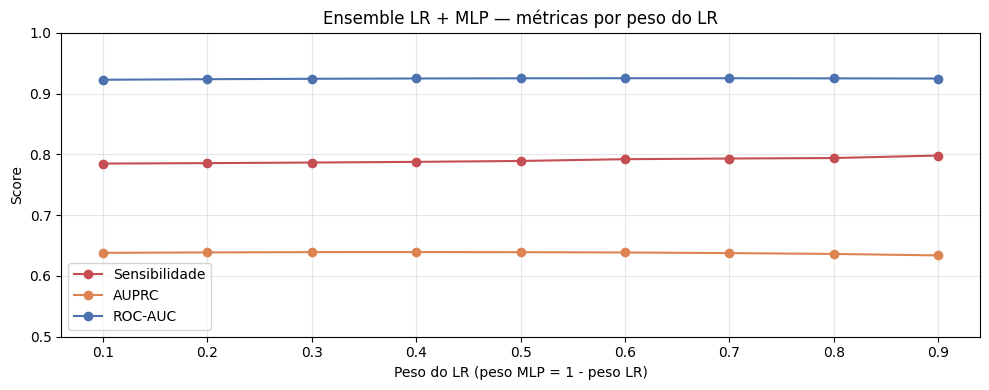

In [6]:
pesos_lr = np.arange(0.1, 1.0, 0.1)
rows_w   = []

for w_lr in pesos_lr:
    w_mlp = round(1 - w_lr, 1)
    p_w   = w_lr * probas['lr'] + w_mlp * probas['mlp']
    m     = calcular_metricas(y_te, p_w)
    rows_w.append({'w_lr': round(w_lr, 1), 'w_mlp': w_mlp, **m})

df_pesos = pd.DataFrame(rows_w)
display(df_pesos[['w_lr', 'w_mlp', 'sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1']])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_pesos['w_lr'], df_pesos['sensibilidade'], 'o-', color='#C44E52', label='Sensibilidade')
ax.plot(df_pesos['w_lr'], df_pesos['auprc'],         'o-', color='#DD8452', label='AUPRC')
ax.plot(df_pesos['w_lr'], df_pesos['roc_auc'],       'o-', color='#4C72B0', label='ROC-AUC')
ax.set_title('Ensemble LR + MLP — métricas por peso do LR')
ax.set_xlabel('Peso do LR (peso MLP = 1 - peso LR)')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Melhor ensemble — avaliação completa

Melhor ensemble: lr + lr_tuned + mlp + lgbm_tuned

=== Métricas ===
  sensibilidade: 0.7843
  especificidade: 0.9087
  auprc: 0.6472
  roc_auc: 0.9261
  f1: 0.3517
  precisao: 0.2266
  threshold: 0.5

              precision    recall  f1-score   support

        Cura       0.99      0.91      0.95    155239
       Óbito       0.23      0.78      0.35      5295

    accuracy                           0.90    160534
   macro avg       0.61      0.85      0.65    160534
weighted avg       0.97      0.90      0.93    160534



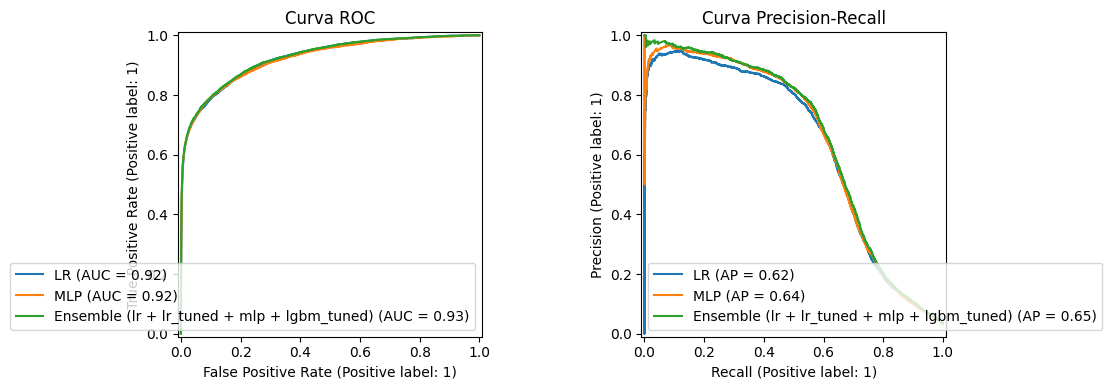

In [7]:
# Seleciona o melhor ensemble por AUPRC entre todas as combinações testadas
melhor = df_combos.iloc[0]
nomes_melhor = melhor['modelos'].split(' + ')
proba_melhor = np.mean([probas[n] for n in nomes_melhor], axis=0)

metricas_melhor = calcular_metricas(y_te, proba_melhor)

print(f'Melhor ensemble: {melhor["modelos"]}')
print()
print('=== Métricas ===')
for k, v in metricas_melhor.items():
    print(f'  {k}: {v}')

print()
print(classification_report(y_te, (proba_melhor >= 0.5).astype(int), target_names=['Cura', 'Óbito']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, probas['lr'],    ax=axes[0], name='LR')
RocCurveDisplay.from_predictions(y_te, probas['mlp'],   ax=axes[0], name='MLP')
RocCurveDisplay.from_predictions(y_te, proba_melhor,    ax=axes[0], name=f'Ensemble ({melhor["modelos"]})')
axes[0].set_title('Curva ROC')

PrecisionRecallDisplay.from_predictions(y_te, probas['lr'],  ax=axes[1], name='LR')
PrecisionRecallDisplay.from_predictions(y_te, probas['mlp'], ax=axes[1], name='MLP')
PrecisionRecallDisplay.from_predictions(y_te, proba_melhor,  ax=axes[1], name=f'Ensemble ({melhor["modelos"]})')
axes[1].set_title('Curva Precision-Recall')
plt.tight_layout()
plt.show()

## 7. Matriz de Confusão — Melhor Ensemble (threshold = 0.5)

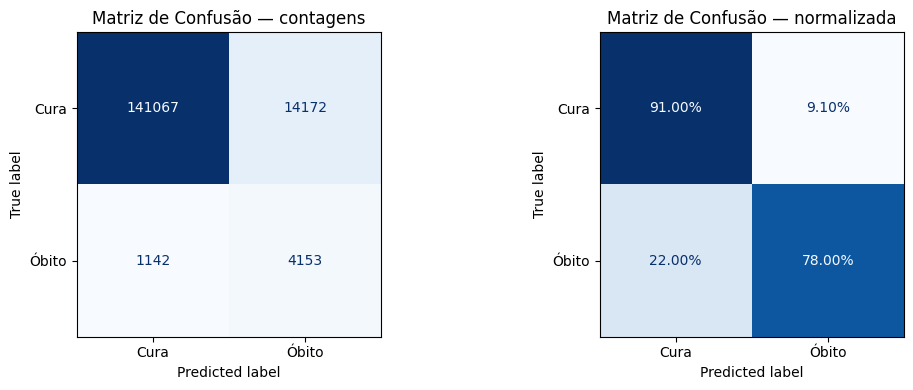

VP (óbitos detectados):   4,153
FN (óbitos perdidos):     1,142
FP (falsos alarmes):      14,172
VN (curas classificadas): 141,067


In [8]:
y_pred_05      = (proba_melhor >= 0.5).astype(int)
cm             = confusion_matrix(y_te, y_pred_05)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(cm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — contagens')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Cura', 'Óbito']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — normalizada')
for text in axes[1].texts:
    text.set_text(f'{float(text.get_text()):.2%}')

plt.tight_layout()
plt.show()

print(f'VP (óbitos detectados):   {tp:,}')
print(f'FN (óbitos perdidos):     {fn:,}')
print(f'FP (falsos alarmes):      {fp:,}')
print(f'VN (curas classificadas): {tn:,}')

## 8. Salvamento

In [9]:
os.makedirs(OUTPUT_MET, exist_ok=True)

label_ensemble = 'ensemble_' + '_'.join(nomes_melhor)

df_met = pd.DataFrame([metricas_melhor])
df_met['label']   = label_ensemble
df_met['dataset'] = 'baseline'
df_met['modelos'] = melhor['modelos']
met_path = os.path.join(OUTPUT_MET, f'{label_ensemble}.parquet')
df_met.to_parquet(met_path, index=False)
print(f'Métricas salvas: {met_path}')

df_pred = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba_melhor})
pred_path = os.path.join(OUTPUT_MET, f'{label_ensemble}_predicoes.parquet')
df_pred.to_parquet(pred_path, index=False)
print(f'Predições salvas: {pred_path}')

Métricas salvas: ../../output/metricas/ensemble_lr_lr_tuned_mlp_lgbm_tuned.parquet
Predições salvas: ../../output/metricas/ensemble_lr_lr_tuned_mlp_lgbm_tuned_predicoes.parquet
